In [1]:
!pip install -q Sastrawi tensorflow scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.6 MB/s eta 0:00:00


In [2]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Semua library berhasil diimport")

Semua library berhasil diimport


In [3]:
df_raw = pd.read_csv('Sentimen_Cleaned.csv')
df = df_raw[['Kritik dan saran', 'Sentimen']].dropna().copy()
df.columns = ['text', 'label_lama']
df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 0].reset_index(drop=True)

print("Data awal:", df.shape)
print("Distribusi label lama:")
print(df['label_lama'].value_counts())
print()
print(df['label_lama'].value_counts(normalize=True).round(3))

Data awal: (8024, 2)
Distribusi label lama:
label_lama
positif    4126
netral     2702
negatif    1196
Name: count, dtype: int64

label_lama
positif    0.514
netral     0.337
negatif    0.149
Name: proportion, dtype: float64


In [4]:
NEGATIF_KUAT = [
    'error','eror','ngelag','lemot','lambat','down','crash','lag',
    'tidak bisa','gabisa','gak bisa','ga bisa','susah','sulit',
    'kecewa','mengecewakan','kecewain','buruk','jelek','parah',
    'kacau','berantakan','amburadul','membingungkan','bingung',
    'membosankan','bosan','boring','monoton',
    'panas','ga dikasih','tidak dikasih','kurang makan','tidak makan',
    'desak','penuh sesak','macet','berdesakan','sesak',
    'ribet','rumit','gak jelas','ngga jelas',
    'tidak kondusif','kurang kondusif','tidak nyaman','kurang nyaman',
    'molor','telat','terlambat','delay','tidak tepat waktu',
    'tidak terorganisir','kurang terorganisir','tidak sigap',
    'tidak responsif','kurang responsif','tidak profesional',
    'tidak efektif','kurang efektif','tidak efisien','kurang efisien',
    'tidak interaktif','kurang interaktif',
    'tidak jelas','kurang jelas','tidak lengkap','kurang lengkap',
    'tidak memuaskan','kurang memuaskan','tidak puas','kurang puas',
    'tidak relevan','kurang relevan','tidak berguna','kurang berguna',
    'tidak membantu','kurang membantu',
    'terlalu lama','terlalu panjang','terlalu banyak joget','kebanyakan joget',
    'kurang fasilitas','kurang kursi','kurang proyektor','kurang ac',
    'ac tidak','ac kurang','proyektor tidak','proyektor kurang',
    'server full','server down','server error','server tidak',
    'link tidak','link susah','link error','link mati',
    'website tidak','website error','website lambat','website lemot',
    'web tidak','web error','web lambat','web lemot','web susah',
    'login tidak','login susah','login error','login gagal',
    'akses tidak','tidak dapat diakses','tidak bisa diakses',
    'tidak bisa masuk','tidak bisa submit','tidak bisa upload',
    'sinyal','koneksi buruk','jaringan buruk','internet lambat',
    'tidak ada konsumsi','tidak dikasih makan','kurang konsumsi',
    'tidak ada snack','lapar',
    'terlalu formal','tidak seru','tidak menarik','tidak asik',
]

POSITIF_KUAT = [
    'bagus','baik','keren','mantap','mantul','luar biasa','hebat',
    'menyenangkan','menarik','interaktif','seru','asik','asyik',
    'informatif','bermanfaat','berguna','membantu','memuaskan',
    'puas','senang','bangga','terkesan','berkesan',
    'profesional','terorganisir','terstruktur','rapi','lancar',
    'tepat waktu','sesuai harapan','sesuai ekspektasi',
    'ramah','komunikatif','responsif','sigap','perhatian',
    'kreatif','inovatif','inspiratif','motivatif','edukatif',
    'sempurna','perfect','nice','amazing','kece',
    'terima kasih','terimakasih','makasih','syukur',
    'jaya','sukses','maju','berkembang',
    'sudah baik','sudah bagus','sudah cukup','sudah oke','sudah keren',
    'sangat baik','sangat bagus','sangat keren','sangat menarik',
    'sangat bermanfaat','sangat membantu','sangat informatif',
    'sangat menyenangkan','sangat puas','sangat senang',
]

NETRAL_MURNI_PATTERNS = [
    r'^[\.\,\-\_\!\?\s]+$',
    r'^[a-zA-Z\s]{1,4}$',
    r'^\d+$',
    r'^(oke|ok|ya|yap|yep|hmm|hm|wkwk|haha|hehe|hihi)+$',
    r'^tidak ada\.?$',
    r'^tiada$',
    r'^ga ada$',
    r'^gada$',
    r'^-$',
    r'^\.+$',
]

TIDAK_ADA_POSITIF = re.compile(
    r'tidak ada.{0,60}(masuk|saran|kritik|keluhan|kekurangan|komplain|komen|catatan)',
    re.IGNORECASE
)

TIDAK_NEGATIF_KONTEKS = re.compile(
    r'tidak\s+(bisa|dapat|error|jelas|kondusif|nyaman|puas|memuaskan|'
    r'efektif|efisien|interaktif|responsif|sigap|profesional|terorganisir|'
    r'relevan|berguna|membantu|dikasih|dapat diakses|bisa diakses|'
    r'bisa masuk|bisa akses)',
    re.IGNORECASE
)

print("Regex patterns dan keyword sets siap")

Regex patterns dan keyword sets siap


In [5]:
def is_netral_murni(text):
    t = text.strip().lower()
    if len(t) <= 3:
        return True
    for pattern in NETRAL_MURNI_PATTERNS:
        if re.fullmatch(pattern, t, re.IGNORECASE):
            return True
    return False

def hitung_skor(text):
    t = text.lower()
    skor_neg = sum(2 for kw in NEGATIF_KUAT if kw in t)
    skor_pos = sum(1 for kw in POSITIF_KUAT if kw in t)

    if TIDAK_ADA_POSITIF.search(text):
        skor_pos += 4
        skor_neg = max(0, skor_neg - 3)

    if TIDAK_NEGATIF_KONTEKS.search(text):
        skor_neg += 3

    return skor_neg, skor_pos

def relabel(text):
    if is_netral_murni(text):
        return 'netral'

    skor_neg, skor_pos = hitung_skor(text)

    if skor_neg == 0 and skor_pos == 0:
        t = text.lower()
        kata_aksi = re.findall(
            r'(?:perbaiki|benerin|tingkatkan|harap|semoga|mohon|tolong)\s+(\w+)', t
        )
        target_neg = ['web','website','server','sistem','link','akses','error','lemot','lambat']
        target_pos = ['pkkmb','acara','kegiatan','unpam','kampus','panitia','semua']
        if any(k in target_neg for k in kata_aksi):
            return 'negatif'
        if any(k in target_pos for k in kata_aksi):
            return 'positif'
        return 'netral'

    if skor_neg > skor_pos:
        return 'negatif'
    elif skor_pos > skor_neg:
        return 'positif'
    return 'netral'

print("Fungsi relabeling siap")

Fungsi relabeling siap


In [6]:
df['label_baru'] = df['text'].apply(relabel)

print("Distribusi label BARU:")
print(df['label_baru'].value_counts())
print()
print(df['label_baru'].value_counts(normalize=True).round(3))
print()
print("Crosstab perubahan label:")
print(pd.crosstab(df['label_lama'], df['label_baru']))

Distribusi label BARU:
label_baru
positif    3691
negatif    2491
netral     1842
Name: count, dtype: int64

label_baru
positif    0.46
negatif    0.31
netral     0.23
Name: proportion, dtype: float64

Crosstab perubahan label:
label_baru  negatif  netral  positif
label_lama                          
negatif         915     155      126
netral          976    1111      615
positif         600     576     2950


In [7]:
test_cases = [
    ('membosankan', 'negatif'),
    ('panas banget, ga dikasih makan juga', 'negatif'),
    ('tidak ada masukan, sudah bagus', 'positif'),
    ('tidak bisa akses website sama sekali', 'negatif'),
    ('terima kasih sudah mengadakan pkkmb', 'positif'),
    ('web error terus parah banget', 'negatif'),
    ('.', 'netral'),
    ('ok', 'netral'),
    ('-', 'netral'),
    ('tidak ada', 'netral'),
    ('pkkmb sangat menyenangkan dan informatif', 'positif'),
    ('server ngelag parah tidak bisa login', 'negatif'),
    ('acara keren banget panitia ramah', 'positif'),
    ('website lemot banget ga bisa submit tugas', 'negatif'),
    ('Tidak ada masukan karna pkkmb tahun ini sudah sangat bagus', 'positif'),
]

print("=== VALIDASI RELABELING ===")
benar = 0
for text, ekspektasi in test_cases:
    hasil = relabel(text)
    status = 'OK' if hasil == ekspektasi else 'SALAH'
    if hasil == ekspektasi:
        benar += 1
    print(f"  [{status}] [{hasil.upper():7}] {text[:50]}")

print(f"\nAkurasi validasi: {benar}/{len(test_cases)} = {benar/len(test_cases)*100:.0f}%")

=== VALIDASI RELABELING ===
  [OK] [NEGATIF] membosankan
  [OK] [NEGATIF] panas banget, ga dikasih makan juga
  [OK] [POSITIF] tidak ada masukan, sudah bagus
  [OK] [NEGATIF] tidak bisa akses website sama sekali
  [OK] [POSITIF] terima kasih sudah mengadakan pkkmb
  [OK] [NEGATIF] web error terus parah banget
  [OK] [NETRAL ] .
  [OK] [NETRAL ] ok
  [OK] [NETRAL ] -
  [OK] [NETRAL ] tidak ada
  [OK] [POSITIF] pkkmb sangat menyenangkan dan informatif
  [OK] [NEGATIF] server ngelag parah tidak bisa login
  [OK] [POSITIF] acara keren banget panitia ramah
  [OK] [NEGATIF] website lemot banget ga bisa submit tugas
  [OK] [POSITIF] Tidak ada masukan karna pkkmb tahun ini sudah sang

Akurasi validasi: 15/15 = 100%


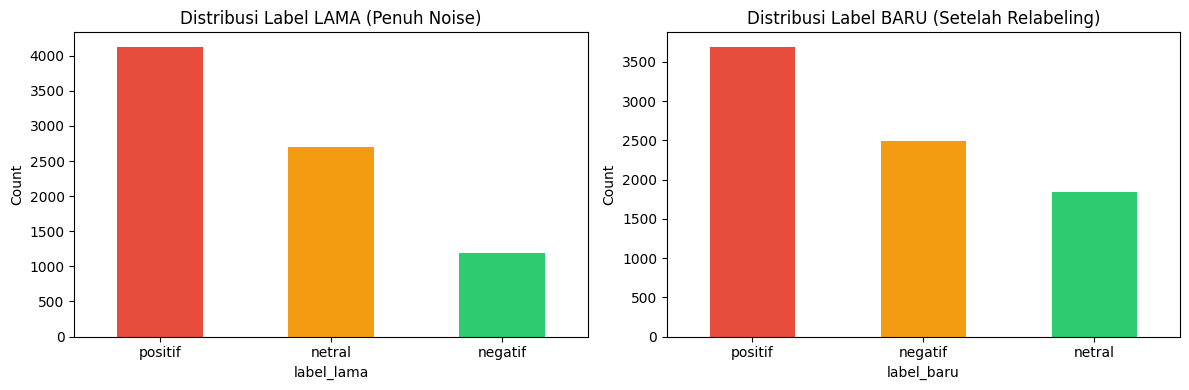

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label_lama'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c','#f39c12','#2ecc71']
)
axes[0].set_title('Distribusi Label LAMA (Penuh Noise)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df['label_baru'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#f39c12','#2ecc71']
)
axes[1].set_title('Distribusi Label BARU (Setelah Relabeling)')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
_stem_factory = StemmerFactory()
_stemmer = _stem_factory.create_stemmer()

_sw_factory = StopWordRemoverFactory()
_all_stopwords = set(_sw_factory.get_stop_words())

_sentiment_keep = {
    'tidak','tak','bukan','tanpa','jangan','belum','namun','tapi','tetapi',
    'sangat','sekali','banget','amat','terlalu','lebih','kurang','cukup',
    'agak','lumayan','sedikit','banyak',
    'baik','bagus','buruk','jelek','enak','susah','mudah','sulit','gampang',
    'senang','puas','kecewa','nyaman','aman','bahaya','parah','berat',
    'seru','membosankan','menarik','membingungkan','menyenangkan','mengecewakan',
    'cepat','lambat','lancar','error','gagal','berhasil','ngelag','lag',
    'perlu','harus','bisa','mampu','ingin','mau','butuh',
    'semoga','harap','tolong','mohon',
    'penting','kritis',
    'kacau','berantakan','amburadul',
    'bosen','bosan','capek','lelah','males','malas',
    'keren','mantap','hebat','oke','ok',
    'sayang','sayangnya',
    'ribet','rumit',
    'nggak','engga','enggak','gak','ga','ngga',
    'memprihatinkan','mengecewakan',
}

_stopwords_filtered = _all_stopwords - _sentiment_keep

_slang_dict = {
    "ga":"tidak","gak":"tidak","gk":"tidak","ngga":"tidak",
    "nggak":"tidak","enggak":"tidak","engga":"tidak",
    "kagak":"tidak","kaga":"tidak","gakbisa":"tidak bisa",
    "bgt":"banget","bngt":"banget","bgtt":"banget",
    "yg":"yang","dgn":"dengan","utk":"untuk","krn":"karena",
    "sdh":"sudah","blm":"belum","jg":"juga","lg":"lagi",
    "tp":"tapi","gpp":"tidak apa","mksh":"terima kasih","tks":"terima kasih",
    "makasih":"terima kasih","makasi":"terima kasih",
    "moga":"semoga","smg":"semoga",
    "lmyn":"lumayan",
    "ngeleg":"ngelag","loading":"lambat",
    "eror":"error","err":"error",
    "oke":"ok","okee":"ok",
    "klo":"kalau","klu":"kalau","kl":"kalau","klw":"kalau",
    "udh":"sudah","udah":"sudah","dah":"sudah",
    "bener":"benar","bner":"benar",
    "gmn":"bagaimana","gimana":"bagaimana",
    "knp":"kenapa","kpn":"kapan",
    "mhs":"mahasiswa","maba":"mahasiswa baru",
    "pnitia":"panitia",
    "down":"mati",
    "smpb":"spmb","ppkmb":"pkkmb","pkmb":"pkkmb",
    "mau":"ingin","pengen":"ingin","pengin":"ingin",
    "cape":"capek",
    "boring":"membosankan","bored":"bosan","bore":"bosan",
    "bad":"buruk","good":"baik",
    "thanks":"terima kasih","thx":"terima kasih","ty":"terima kasih",
    "mantul":"mantap",
    "parah":"parah","ancur":"hancur",
}

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [_slang_dict.get(w, w) for w in tokens]
    tokens = [w for w in tokens if w not in _stopwords_filtered and len(w) > 1]
    text = ' '.join(tokens)
    text = _stemmer.stem(text)
    return text.strip()

print("Preprocessing pipeline siap")

Preprocessing pipeline siap


In [10]:
samples = [
    "membosankan",
    "panas banget, ga dikasih makan juga",
    "website ngelag parah banget gak bisa akses sama sekali",
    "sangat puas dengan pelaksanaan PKKMB tahun ini",
    "tidak ada masukan, sudah bagus",
]

print("=== SAMPLE PREPROCESSING ===")
for s in samples:
    print(f"IN : {s}")
    print(f"OUT: {preprocess(s)}")
    print()

=== SAMPLE PREPROCESSING ===
IN : membosankan
OUT: bosan

IN : panas banget, ga dikasih makan juga
OUT: panas banget tidak kasih makan

IN : website ngelag parah banget gak bisa akses sama sekali
OUT: website ngelag parah banget tidak bisa akses sama sekali

IN : sangat puas dengan pelaksanaan PKKMB tahun ini
OUT: sangat puas laksana pkkmb tahun

IN : tidak ada masukan, sudah bagus
OUT: tidak masuk bagus



In [11]:
print("Applying preprocessing to all data...")
df['clean_text'] = df['text'].apply(preprocess)
df_model = df[df['clean_text'].str.strip().str.len() > 0].copy()

label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df_model['label_int'] = df_model['label_baru'].map(label_map).astype(int)

print("Shape setelah preprocessing:", df_model.shape)
print("Distribusi final:")
print(df_model['label_baru'].value_counts())
print()
print(df_model['label_baru'].value_counts(normalize=True).round(3))

Applying preprocessing to all data...
Shape setelah preprocessing: (8009, 5)
Distribusi final:
label_baru
positif    3690
negatif    2491
netral     1828
Name: count, dtype: int64

label_baru
positif    0.461
negatif    0.311
netral     0.228
Name: proportion, dtype: float64


In [12]:
augmented_negative = [
    "servernya full error susah kerja",
    "website ngelag tidak bisa akses",
    "login susah server lambat parah",
    "sistem eror terus tidak bisa masuk",
    "link tidak bisa dibuka ngelag banget",
    "web pkkmb sangat lambat tidak nyaman",
    "tidak bisa akses sama sekali error",
    "server down tidak bisa login",
    "website error terus parah banget",
    "susah akses web pkkmb online",
    "pkkmb membosankan tidak ada manfaat",
    "acara tidak menarik sama sekali",
    "materi tidak jelas membingungkan",
    "sangat mengecewakan tidak edukatif",
    "pkkmb tidak kondusif kacau",
    "tidak seru sama sekali buang waktu",
    "sangat kecewa dengan pelaksanaan pkkmb",
    "panitia tidak profesional acara berantakan",
    "pkkmb berantakan tidak terorganisir",
    "tidak ada manfaat membuang waktu",
    "materi tidak sampai membingungkan",
    "informasi tidak jelas kurang sosialisasi",
    "jadwal tidak tepat waktu molor terus",
    "koordinasi panitia sangat buruk",
    "tidak komunikatif informasi kurang jelas",
    "pkkmb online sangat membosankan",
    "kurang persiapan acara tidak matang",
    "sistem tidak user friendly sulit digunakan",
    "tidak nyaman sama sekali acara kacau",
    "terlalu banyak joget tidak edukatif",
]

augmented_neutral = [
    "terima kasih",
    "terimakasih",
    "semoga",
    "oke",
    "baik",
    "cukup",
    "tidak ada",
    "ga ada",
]

augmented_positive = [
    "pkkmb sangat menyenangkan dan informatif sekali",
    "panitia sangat ramah dan membantu mahasiswa baru",
    "acara pkkmb luar biasa terima kasih panitia",
    "materi pkkmb sangat berguna dan relevan",
    "sistem pkkmb tahun ini jauh lebih baik",
    "sangat puas dengan pelaksanaan pkkmb",
    "pkkmb memberikan banyak manfaat bagi mahasiswa baru",
    "senang bisa ikut pkkmb yang sangat bermakna",
    "acara berjalan lancar dan menyenangkan",
    "informasi disampaikan dengan jelas dan menarik",
    "pkkmb tahun ini keren banget mantap panitia",
    "sangat terkesan dengan persiapan panitia yang matang",
    "website pkkmb mudah diakses dan user friendly",
    "sistem berjalan lancar tidak ada kendala",
    "pkkmb sangat membantu adaptasi di kampus baru",
]

df_aug_neg = pd.DataFrame({
    'clean_text': [preprocess(t) for t in augmented_negative],
    'label_int': 0, 'label_baru': 'negatif'
})
df_aug_neu = pd.DataFrame({
    'clean_text': [preprocess(t) for t in augmented_neutral],
    'label_int': 1, 'label_baru': 'netral'
})
df_aug_pos = pd.DataFrame({
    'clean_text': [preprocess(t) for t in augmented_positive],
    'label_int': 2, 'label_baru': 'positif'
})

df_combined = pd.concat([
    df_model[['clean_text','label_int','label_baru']],
    df_aug_neg, df_aug_neu, df_aug_pos
], ignore_index=True)
df_combined = df_combined[df_combined['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

print("Setelah augmentasi:")
print(df_combined['label_baru'].value_counts())
print()
print(df_combined['label_baru'].value_counts(normalize=True).round(3))

Setelah augmentasi:
label_baru
positif    3705
negatif    2521
netral     1836
Name: count, dtype: int64

label_baru
positif    0.460
negatif    0.313
netral     0.228
Name: proportion, dtype: float64


Distribusi setelah balancing:
label_baru
positif    3000
negatif    3000
netral     3000
Name: count, dtype: int64

label_baru
positif    0.333
negatif    0.333
netral     0.333
Name: proportion, dtype: float64


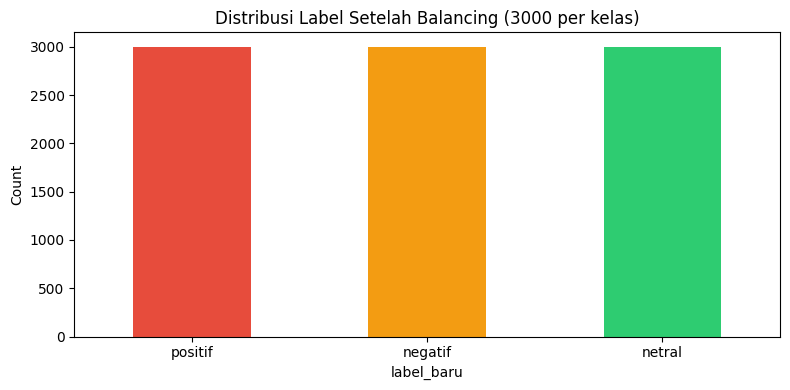

In [13]:
from sklearn.utils import resample

df_neg = df_combined[df_combined['label_int'] == 0]
df_neu = df_combined[df_combined['label_int'] == 1]
df_pos = df_combined[df_combined['label_int'] == 2]

TARGET = 3000

df_neg_up  = resample(df_neg, replace=True, n_samples=TARGET, random_state=42)
df_neu_bal = resample(df_neu, replace=len(df_neu)<TARGET, n_samples=TARGET, random_state=42)
df_pos_bal = resample(df_pos, replace=False, n_samples=TARGET, random_state=42)

df_balanced = pd.concat([df_neg_up, df_neu_bal, df_pos_bal], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi setelah balancing:")
print(df_balanced['label_baru'].value_counts())
print()
print(df_balanced['label_baru'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(8, 4))
df_balanced['label_baru'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#f39c12','#2ecc71'])
ax.set_title('Distribusi Label Setelah Balancing (3000 per kelas)')
ax.set_ylabel('Count')
ax.tick_params(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
X = df_balanced['clean_text'].values
y = df_balanced['label_int'].values.astype(np.int32)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Val: {len(X_val)}")
print("Train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val distribution  :", dict(zip(*np.unique(y_val, return_counts=True))))

Train: 7200 | Val: 1800
Train distribution: {np.int32(0): np.int64(2400), np.int32(1): np.int64(2400), np.int32(2): np.int64(2400)}
Val distribution  : {np.int32(0): np.int64(600), np.int32(1): np.int64(600), np.int32(2): np.int64(600)}


In [15]:
MAX_VOCAB = 12000
MAX_LEN = 50

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    ngrams=2,
    name='text_vectorizer'
)

vectorizer.adapt(X_train)

vocab = vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample vocab: {vocab[100:110]}")

with open("vectorizer_config.json", "w", encoding="utf-8") as f:
    json.dump({"config": vectorizer.get_config(), "vocabulary": vocab}, f, ensure_ascii=False)
print("vectorizer_config.json disimpan")

X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)
print("X_train_vec shape:", X_train_vec.shape)
print("X_val_vec shape  :", X_val_vec.shape)

Vocabulary size: 12000
Sample vocab: [np.str_('kalau'), np.str_('sekali'), np.str_('suasana'), np.str_('lebih seru'), np.str_('kendala'), np.str_('bosan'), np.str_('asa'), np.str_('tetapi'), np.str_('lanjut'), np.str_('makin')]
vectorizer_config.json disimpan
X_train_vec shape: (7200, 50)
X_val_vec shape  : (1800, 50)


In [16]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * inputs
        return tf.reduce_sum(context, axis=1)

    def get_config(self):
        return super(AttentionLayer, self).get_config()

print("AttentionLayer (Custom Layer) siap")

AttentionLayer (Custom Layer) siap


In [17]:
class WeightedSparseCCE(tf.keras.losses.Loss):
    def __init__(self, class_weights_dict, **kwargs):
        super(WeightedSparseCCE, self).__init__(**kwargs)
        self.class_weights_dict = class_weights_dict
        self._weights_tensor = tf.constant(
            [class_weights_dict[i] for i in sorted(class_weights_dict)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        cce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        sample_weights = tf.gather(self._weights_tensor, y_int)
        return tf.reduce_mean(sample_weights * cce)

    def get_config(self):
        config = super(WeightedSparseCCE, self).get_config()
        config.update({'class_weights_dict': {int(k): float(v) for k, v in self.class_weights_dict.items()}})
        return config

cw_array = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(cw_array)}
print("Class weights:", class_weights)

weighted_loss = WeightedSparseCCE(class_weights)
print("WeightedSparseCCE (Custom Loss) siap")

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}
WeightedSparseCCE (Custom Loss) siap


In [18]:
class DetailedLoggingCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        print("=" * 60)
        print("Training Dimulai")
        print("=" * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        tr_acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        tr_loss = logs.get('loss', 0)
        vl_loss = logs.get('val_loss', 0)
        gap = tr_acc - val_acc
        status = "OVERFIT" if gap > 0.10 else "OK"
        print(f"Epoch {epoch+1:02d} | loss: {tr_loss:.4f} acc: {tr_acc:.4f} | val_loss: {vl_loss:.4f} val_acc: {val_acc:.4f} | gap: {gap:.4f} [{status}]")

    def on_train_end(self, logs=None):
        print("=" * 60)
        print("Training Selesai")
        print("=" * 60)

detailed_cb = DetailedLoggingCallback()
print("DetailedLoggingCallback (Custom Callback) siap")

DetailedLoggingCallback (Custom Callback) siap


In [19]:
def build_model(max_vocab=MAX_VOCAB, max_len=MAX_LEN, embed_dim=64, num_classes=3):
    inputs = tf.keras.Input(shape=(max_len,), name='input_text')

    x = tf.keras.layers.Embedding(
        input_dim=max_vocab,
        output_dim=embed_dim,
        name='embedding'
    )(inputs)

    x = tf.keras.layers.SpatialDropout1D(0.25, name='spatial_dropout')(x)

    x = tf.keras.layers.Conv1D(
        64, kernel_size=3, padding='same',
        activation='relu', name='conv1'
    )(x)
    x = tf.keras.layers.BatchNormalization(name='bn1')(x)

    x = tf.keras.layers.Conv1D(
        64, kernel_size=3, padding='same',
        activation='relu', name='conv2'
    )(x)

    x_att = AttentionLayer(name='attention')(x)
    x_pool = tf.keras.layers.GlobalMaxPooling1D(name='global_max_pool')(x)
    x_avg = tf.keras.layers.GlobalAveragePooling1D(name='global_avg_pool')(x)

    x = tf.keras.layers.Concatenate(name='concat')([x_att, x_pool, x_avg])

    x = tf.keras.layers.Dense(
        96, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name='dense_1'
    )(x)
    x = tf.keras.layers.Dropout(0.4, name='dropout')(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='sentiment_pkkmb_v2')
    return model

model = build_model()
model.summary()

Model: "sentiment_pkkmb_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    768,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 50, 64)    │     12,352 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 50, 64)    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 50, 64)    │     12,352 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │        114 │ conv2[0][0]       │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 64)        │          0 │ conv2[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 64)        │          0 │ conv2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ global_max_pool[… │
│                     │                   │            │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96)        │     18,528 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        291 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 811,893 (3.10 MB)

 Trainable params: 811,765 (3.10 MB)

 Non-trainable params: 128 (512.00 B)

In [20]:
model.compile(
    loss=weighted_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

print("Model dikompilasi dengan WeightedSparseCCE loss dan Adam optimizer")

Model dikompilasi dengan WeightedSparseCCE loss dan Adam optimizer


In [21]:
log_dir = os.path.join('logs', 'fit')
os.makedirs(log_dir, exist_ok=True)

callbacks_fit = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        min_delta=0.002,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True
    ),
    detailed_cb,
]

BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_fit
)

Training Dimulai
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3723 - loss: 1.1645Epoch 01 | loss: 1.0957 acc: 0.4226 | val_loss: 1.0983 val_acc: 0.4894 | gap: -0.0668 [OK]
113/113 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.4226 - loss: 1.0957 - val_accuracy: 0.4894 - val_loss: 1.0983 - learning_rate: 3.0000e-04
Epoch 2/30
106/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6061 - loss: 0.9040Epoch 02 | loss: 0.8335 acc: 0.6501 | val_loss: 1.0243 val_acc: 0.6533 | gap: -0.0032 [OK]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6501 - loss: 0.8335 - val_accuracy: 0.6533 - val_loss: 1.0243 - learning_rate: 3.0000e-04
Epoch 3/30
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7766 - loss: 0.5879Epoch 03 | loss: 0.5486 acc: 0.7950 | val_loss: 0.8326 val_acc: 0.8206 | gap: -0.0256 [OK]
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7950 - loss: 0.5486 - val_accuracy: 0.8206 - val_loss: 0.8326 - learning_rate: 3.0000e-04
Epoch 4/30
110/1

model.fit — val_loss: 0.2895 | val_accuracy: 0.9061
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

CLASSIFICATION REPORT (model.fit)
              precision    recall  f1-score   support

     negatif       0.94      0.91      0.93       600
      netral       0.94      0.87      0.90       600
     positif       0.85      0.94      0.89       600

    accuracy                           0.91      1800
   macro avg       0.91      0.91      0.91      1800
weighted avg       0.91      0.91      0.91      1800



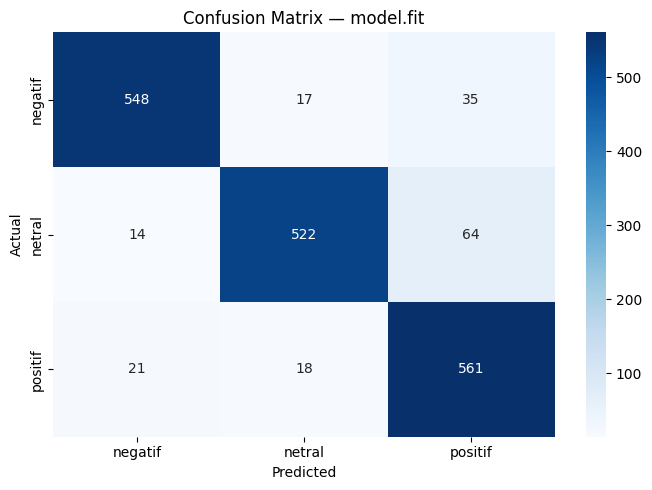

In [22]:
loss_fit, acc_fit = model.evaluate(X_val_vec, y_val, verbose=0)
print(f"model.fit — val_loss: {loss_fit:.4f} | val_accuracy: {acc_fit:.4f}")

y_pred_proba = model.predict(X_val_vec)
y_pred = np.argmax(y_pred_proba, axis=1)

label_names = ['negatif', 'netral', 'positif']
print()
print("=" * 55)
print("CLASSIFICATION REPORT (model.fit)")
print("=" * 55)
print(classification_report(y_val, y_pred, target_names=label_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — model.fit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

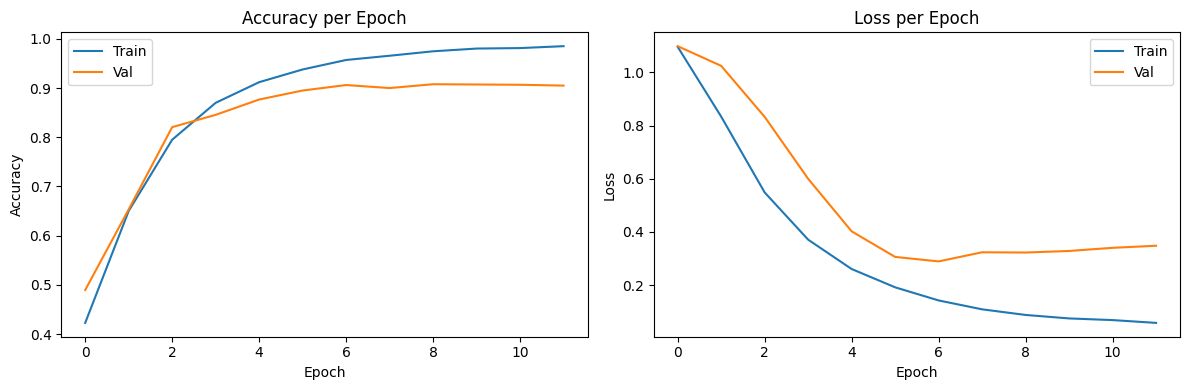

In [23]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
model_gt = build_model()
optimizer_gt = tf.keras.optimizers.Adam(learning_rate=3e-4)
loss_fn_gt = WeightedSparseCCE(class_weights)
train_acc_m = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_m = tf.keras.metrics.SparseCategoricalAccuracy()
train_loss_m = tf.keras.metrics.Mean()

EPOCHS_GT = 20
BATCH_GT = 64
PATIENCE_GT = 5

train_ds_gt = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(len(X_train)).batch(BATCH_GT).prefetch(tf.data.AUTOTUNE)
val_ds_gt = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_GT).prefetch(tf.data.AUTOTUNE)

history_gt = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_cnt = 0

print("Memulai GradientTape custom training loop...")
print("=" * 60)

for epoch in range(EPOCHS_GT):
    train_acc_m.reset_state()
    train_loss_m.reset_state()
    val_acc_m.reset_state()
    val_loss_list = []

    for x_batch, y_batch in train_ds_gt:
        with tf.GradientTape() as tape:
            y_hat = model_gt(x_batch, training=True)
            loss = loss_fn_gt(y_batch, y_hat)
        grads = tape.gradient(loss, model_gt.trainable_variables)
        optimizer_gt.apply_gradients(zip(grads, model_gt.trainable_variables))
        train_acc_m.update_state(y_batch, y_hat)
        train_loss_m.update_state(loss)

    for x_batch, y_batch in val_ds_gt:
        y_hat_val = model_gt(x_batch, training=False)
        val_loss = loss_fn_gt(y_batch, y_hat_val)
        val_acc_m.update_state(y_batch, y_hat_val)
        val_loss_list.append(val_loss.numpy())

    tr_acc = train_acc_m.result().numpy()
    tr_loss = train_loss_m.result().numpy()
    vl_acc = val_acc_m.result().numpy()
    vl_loss = np.mean(val_loss_list)

    history_gt['train_acc'].append(float(tr_acc))
    history_gt['train_loss'].append(float(tr_loss))
    history_gt['val_acc'].append(float(vl_acc))
    history_gt['val_loss'].append(float(vl_loss))

    gap = tr_acc - vl_acc
    status = "OVERFIT" if gap > 0.10 else "OK"
    print(f"Epoch {epoch+1:02d}/{EPOCHS_GT} | loss: {tr_loss:.4f} acc: {tr_acc:.4f} | val_loss: {vl_loss:.4f} val_acc: {vl_acc:.4f} | [{status}]")

    if vl_acc > best_val_acc + 0.002:
        best_val_acc = vl_acc
        model_gt.save_weights('best_gt_weights.weights.h5')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_GT:
            print(f"Early stopping di epoch {epoch+1}")
            break

model_gt.load_weights('best_gt_weights.weights.h5')
print("=" * 60)
print(f"GradientTape training selesai. Best val_acc: {best_val_acc:.4f}")

Memulai GradientTape custom training loop...
Epoch 01/20 | loss: 1.0426 acc: 0.4636 | val_loss: 1.0824 val_acc: 0.5411 | [OK]
Epoch 02/20 | loss: 0.8009 acc: 0.6583 | val_loss: 1.0161 val_acc: 0.6383 | [OK]
Epoch 03/20 | loss: 0.5388 acc: 0.7953 | val_loss: 0.8332 val_acc: 0.7894 | [OK]
Epoch 04/20 | loss: 0.3554 acc: 0.8722 | val_loss: 0.5868 val_acc: 0.8578 | [OK]
Epoch 05/20 | loss: 0.2528 acc: 0.9133 | val_loss: 0.3976 val_acc: 0.8856 | [OK]
Epoch 06/20 | loss: 0.1840 acc: 0.9403 | val_loss: 0.3223 val_acc: 0.8928 | [OK]
Epoch 07/20 | loss: 0.1287 acc: 0.9563 | val_loss: 0.3336 val_acc: 0.8944 | [OK]
Epoch 08/20 | loss: 0.1063 acc: 0.9658 | val_loss: 0.3266 val_acc: 0.8950 | [OK]
Epoch 09/20 | loss: 0.0816 acc: 0.9739 | val_loss: 0.3480 val_acc: 0.8983 | [OK]
Epoch 10/20 | loss: 0.0727 acc: 0.9764 | val_loss: 0.3451 val_acc: 0.9011 | [OK]
Epoch 11/20 | loss: 0.0580 acc: 0.9814 | val_loss: 0.3629 val_acc: 0.9044 | [OK]
Epoch 12/20 | loss: 0.0528 acc: 0.9821 | val_loss: 0.3771 val_ac

GradientTape — val_loss: 0.3566 | val_accuracy: 0.9044
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CLASSIFICATION REPORT (GradientTape)
              precision    recall  f1-score   support

     negatif       0.92      0.92      0.92       600
      netral       0.93      0.87      0.90       600
     positif       0.87      0.93      0.89       600

    accuracy                           0.90      1800
   macro avg       0.91      0.90      0.90      1800
weighted avg       0.91      0.90      0.90      1800



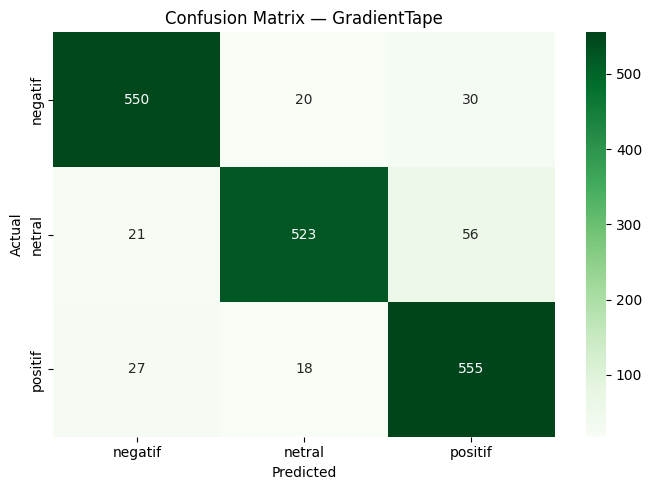

In [25]:
model_gt.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
loss_gt, acc_gt = model_gt.evaluate(X_val_vec, y_val, verbose=0)
print(f"GradientTape — val_loss: {loss_gt:.4f} | val_accuracy: {acc_gt:.4f}")

y_pred_gt = np.argmax(model_gt.predict(X_val_vec), axis=1)
print()
print("=" * 55)
print("CLASSIFICATION REPORT (GradientTape)")
print("=" * 55)
print(classification_report(y_val, y_pred_gt, target_names=label_names))

cm_gt = confusion_matrix(y_val, y_pred_gt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_gt, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — GradientTape')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [26]:
print("=" * 55)
print("PERBANDINGAN MODEL")
print("=" * 55)
print(f"model.fit    → val_accuracy: {acc_fit:.4f}")
print(f"GradientTape → val_accuracy: {acc_gt:.4f}")
print()

if acc_gt > acc_fit:
    best_model = model_gt
    best_name = 'GradientTape'
    best_acc = acc_gt
else:
    best_model = model
    best_name = 'model.fit'
    best_acc = acc_fit

print(f"Model terpilih: {best_name} (val_acc: {best_acc:.4f})")
print()

if best_acc >= 0.85:
    print("Target akurasi >= 85% TERCAPAI ✓")
else:
    print(f"Akurasi saat ini: {best_acc:.4f} — pertimbangkan fine-tuning lebih lanjut")

PERBANDINGAN MODEL
model.fit    → val_accuracy: 0.9061
GradientTape → val_accuracy: 0.9044

Model terpilih: model.fit (val_acc: 0.9061)

Target akurasi >= 85% TERCAPAI ✓


In [27]:
best_model.save('final_model.keras')
print("Model disimpan: final_model.keras")

os.makedirs('saved_model/sentiment_model', exist_ok=True)
best_model.export('saved_model/sentiment_model')
print("SavedModel disimpan: saved_model/sentiment_model")

import shutil
shutil.make_archive('saved_model_folder', 'zip', 'saved_model')
print("Zip file disimpan: saved_model_folder.zip")

Model disimpan: final_model.keras
Saved artifact at 'saved_model/sentiment_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50), dtype=tf.float32, name='input_text')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139923685824784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685826128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685824592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685828624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685829584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685829392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685828432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685829968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685829776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139923685830544: TensorSpec(shape=(), dtype=tf.res

In [28]:
log_dir_gt = os.path.join('logs', 'gradient_tape')
os.makedirs(log_dir_gt, exist_ok=True)

writer_gt = tf.summary.create_file_writer(log_dir_gt)
with writer_gt.as_default():
    for step, (tr_acc, tr_loss, vl_acc, vl_loss) in enumerate(zip(
        history_gt['train_acc'], history_gt['train_loss'],
        history_gt['val_acc'], history_gt['val_loss']
    )):
        tf.summary.scalar('epoch_accuracy', tr_acc, step=step)
        tf.summary.scalar('epoch_val_accuracy', vl_acc, step=step)
        tf.summary.scalar('epoch_loss', tr_loss, step=step)
        tf.summary.scalar('epoch_val_loss', vl_loss, step=step)
    writer_gt.flush()

shutil.make_archive('tensorboard_logs', 'zip', 'logs')
print("TensorBoard logs disimpan: tensorboard_logs.zip")

TensorBoard logs disimpan: tensorboard_logs.zip


In [29]:
_LABEL_MAP = {0: 'negatif', 1: 'netral', 2: 'positif'}
CONFIDENCE_THRESHOLD = 0.45

def predict_sentiment(text: str, model_to_use=None):
    if model_to_use is None:
        model_to_use = best_model

    clean = preprocess(text)

    if not clean.strip():
        return {
            'label': 'netral',
            'confidence': 0.0,
            'probabilitas': {'negatif': 0.0, 'netral': 1.0, 'positif': 0.0},
            'clean_text': clean
        }

    vec = vectorizer([clean])
    proba = model_to_use(vec, training=False).numpy()[0]
    pred_idx = int(np.argmax(proba))
    confidence = float(proba[pred_idx])

    if confidence < CONFIDENCE_THRESHOLD:
        pred_idx = 1

    return {
        'label': _LABEL_MAP[pred_idx],
        'confidence': round(confidence, 4),
        'probabilitas': {
            'negatif': round(float(proba[0]), 4),
            'netral': round(float(proba[1]), 4),
            'positif': round(float(proba[2]), 4),
        },
        'clean_text': clean
    }

print("Inference function siap")

Inference function siap


In [30]:
test_inputs = [
    "membosankan",
    "panas banget, ga dikasih makan juga",
    "tidak ada masukan, sudah bagus",
    "tidak bisa akses website sama sekali",
    "web error terus parah banget",
    "pkkmb sangat menyenangkan terima kasih panitia",
    "server ngelag tidak bisa login parah",
    "acara keren banget sangat informatif",
    ".",
    "ok",
    "Servernya full error jadi agak susah saat mengerjakan",
    "Sudah baik namun akan lebih baik jika dilaksanakan langsung",
    "pkkmb tidak kondusif desak desakan saat keluar",
    "tidak ada kritikan pkkmb sudah sempurna",
    "cuek",
]

print("=" * 65)
print("FINAL INFERENCE TEST")
print("=" * 65)
for txt in test_inputs:
    result = predict_sentiment(txt)
    print(f"Input: {txt[:55]}")
    print(f"  Label: {result['label'].upper()} | Conf: {result['confidence']:.4f}")
    print(f"  Proba: neg={result['probabilitas']['negatif']:.3f} | neu={result['probabilitas']['netral']:.3f} | pos={result['probabilitas']['positif']:.3f}")
    print()

FINAL INFERENCE TEST
Input: membosankan
  Label: NEGATIF | Conf: 0.8221
  Proba: neg=0.822 | neu=0.173 | pos=0.005

Input: panas banget, ga dikasih makan juga
  Label: NEGATIF | Conf: 0.9393
  Proba: neg=0.939 | neu=0.056 | pos=0.005

Input: tidak ada masukan, sudah bagus
  Label: POSITIF | Conf: 0.9997
  Proba: neg=0.000 | neu=0.000 | pos=1.000

Input: tidak bisa akses website sama sekali
  Label: NEGATIF | Conf: 0.9362
  Proba: neg=0.936 | neu=0.063 | pos=0.001

Input: web error terus parah banget
  Label: NEGATIF | Conf: 0.9821
  Proba: neg=0.982 | neu=0.017 | pos=0.001

Input: pkkmb sangat menyenangkan terima kasih panitia
  Label: POSITIF | Conf: 0.9964
  Proba: neg=0.000 | neu=0.003 | pos=0.996

Input: server ngelag tidak bisa login parah
  Label: NEGATIF | Conf: 0.9988
  Proba: neg=0.999 | neu=0.001 | pos=0.001

Input: acara keren banget sangat informatif
  Label: POSITIF | Conf: 0.9877
  Proba: neg=0.003 | neu=0.009 | pos=0.988

Input: .
  Label: NETRAL | Conf: 0.0000
  Proba: 

In [31]:
!pip freeze > requirements.txt

try:
    from google.colab import files
    files.download('final_model.keras')
    files.download('saved_model_folder.zip')
    files.download('tensorboard_logs.zip')
    files.download('vectorizer_config.json')
    files.download('requirements.txt')
    print("Semua file siap didownload")
except ImportError:
    print("Bukan environment Colab — file tersedia di direktori kerja:")
    for f in ['final_model.keras','saved_model_folder.zip','tensorboard_logs.zip','vectorizer_config.json','requirements.txt']:
        exists = os.path.exists(f)
        print(f"  {'OK' if exists else 'MISSING'} — {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Semua file siap didownload
